# # Effectiveness of thrombolysis and thrombectomy in early (6hr) arrivals of non-mild stroke -  Target trial emulation

**Good outcome = discharged mRS or at same mRS as pre-stroke mRS**

See: https://www.nice.org.uk/corporate/ecd9/chapter/overview

Hernán MA, Dahabreh IJ, Dickerman BA, Swanson SA. The Target Trial Framework for Causal Inference From Observational Data: Why and When Is It Helpful? Ann Intern Med. 2025 Mar;178(3):402-407. doi: 10.7326/ANNALS-24-01871.

Cashin, A. G.; Hansford, H. J.; Hernán, M. A.; Swanson, S. A.; Lee, H.; Jones, M. D.; Dahabreh, I. J.; Dickerman, B. A.; Egger, M.; Garcia-Albeniz, X.; Golub, R. M.; Islam, N.; Lodi, S.; Moreno-Betancur, M.; Pearson, S.-A.; Schneeweiss, S.; Sharp, M. K.; Sterne, J. A. C.; Stuart, E. A.; McAuley, J. H. Transparent Reporting of Observational Studies Emulating a Target Trial—The TARGET Statement. 

JAMA 2025, 334 (12), 1084–1093. https://doi.org/10.1001/jama.2025.13350

BMJ 2025. https://doi.org/10.1136/bmj-2025-087179

YouTube videos on Target Trial Emulation:

https://www.youtube.com/watch?v=eWImwOCZndU

https://www.youtube.com/watch?v=UhmW4U_9vvA

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [2]:
prefix = "non_mild_stroke_early_arrival_good_outcome_target_trial"
MRS_TARGET = 2
CUTOFF = 270

## Define fields

In [3]:
DESCRIPTIVE_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'length_of_stay',
    'discharge_disability',
    'thrombolysis_induced_haemorrhage',
    'death',
]

MATCHING_FEATURES = [
    'prior_disability',
    'stroke_severity_band',
    'age',
    'afib_anticoagulant',
    'any_afib_diagnosis',

]

ALL_FEATURES = list(set(DESCRIPTIVE_FEATURES + 
                        ['onset_to_thrombolysis_time', 'onset_to_thrombectomy_time', 'discharge_disability']))

## Load and filter data

In [4]:
data = pd.read_csv("../data/sam3/cleaned_data.csv", low_memory=False)

# Calculate onset_to_scan
data["onset_to_scan_time"] = data["onset_to_arrival_time"] - data["arrival_to_scan_time"]

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]
print(f"Final data shape: {data.shape}")

# Select features 
data = data[ALL_FEATURES]

# Add stroke_severity_band
data["stroke_severity_band"] = (
    pd.to_numeric(data["stroke_severity"], errors="coerce")
    .floordiv(5)
    .astype("Int64")
)

# Add outcome variable: mRS <= MRS_TARGET or return to pre-stroke mRS
data["outcome_target"] = (
    (data["discharge_disability"] <= MRS_TARGET)
    | (data["discharge_disability"] <= data["prior_disability"])
).astype(int)

data["outcome_target"] = data["outcome_target"].astype(int)

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")

Initial data shape: (452863, 73)
Final data shape: (74678, 73)
Number of patients with thrombectomy: 8147
Number of patients with both thrombolysis and thrombectomy: 5164
Number of patients with only thrombectomy: 2983
Number of patients with thrombolysis: 34048
Number of patients with only thrombolysis: 28884


Add treatment columns and patient ID (for honest splitting) for Causal Forest

In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"
    # Early thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    # Late thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    # Early thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF), 
             "treatment_group"] = "early_thrombectomy_only"
    # Late thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    # Early thrombolysis and early thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    # Early thrombolysis and late thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) & 
             (data[TIME_THROMBECTOMY] != 99999), 
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    # Late both thrombolysis and thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) &(data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    return data

data = add_treatment_columns(data)

data["patient_id"] = np.arange(len(data))

In [6]:
# Create treatment groups depending  on whether no treatment, thrombolysis only, thrombectomy only,
# or both treatments. Ignore time to treatment.

def add_treatment_type(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_type"] = "neither"
    # Thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_type"] = "thrombolysis_only"
    # Thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "thrombectomy_only"
    # Both treatments
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "both"

    return data

data = add_treatment_type(data)

## Matching

In [7]:
control_group_name = "neither"
treatment_groups = sorted(
    group for group in data["treatment_group"].dropna().unique()
    if group != control_group_name
)

matched_samples = {}
summary_rows = []
summary_rows_target = []

for group_name in treatment_groups:
    treated_group = data[data["treatment_group"] == group_name]
    untreated_group = data[data["treatment_group"] == control_group_name]

    if treated_group.empty or untreated_group.empty:
        continue

    target_treated = []
    target_untreated = []
    count = 0
    matched = 0
    unmatched = 0

    while count < len(treated_group):
        # Get a treated patient using the count as index to ensure we sample each treated patient in order
        treated_patient = treated_group.iloc[[count]]
        treated_row = treated_patient.iloc[0]
        count += 1

        matching_untreated = untreated_group
        for feature_name in MATCHING_FEATURES:
            matching_untreated = matching_untreated[
                matching_untreated[feature_name] == treated_row[feature_name]
            ]

        if len(matching_untreated) > 0:
            untreated_patient = matching_untreated.sample(
                n=1, random_state=42 + count
            )
            target_treated.append(treated_patient)
            target_untreated.append(untreated_patient)
            matched += 1
        else:
            unmatched += 1

    percent_matched = 100 * matched / (matched + unmatched)

    target_treated_df = pd.concat(target_treated).reset_index(drop=True)
    target_untreated_df = pd.concat(target_untreated).reset_index(drop=True)

    matched_samples[group_name] = {
        "treated": target_treated_df,
        "untreated": target_untreated_df,
    }

    # Summary for discharge_disability
    treated_mean = target_treated_df["discharge_disability"].mean()
    untreated_mean = target_untreated_df["discharge_disability"].mean()
    treated_ci = sm.stats.DescrStatsW(
        target_treated_df["discharge_disability"]
    ).tconfint_mean(alpha=0.05)
    untreated_ci = sm.stats.DescrStatsW(
        target_untreated_df["discharge_disability"]
    ).tconfint_mean(alpha=0.05)
    ttest_result = sm.stats.ttest_ind(
        target_treated_df["discharge_disability"],
        target_untreated_df["discharge_disability"],
    )
    t_stat, p_value = ttest_result[0], ttest_result[1]

    summary_rows.append({
        "treatment_group": group_name,
        "matched_n": matched,
        "percent_matched": percent_matched,
        "treated_mean": treated_mean,
        "treated_ci_lower": treated_ci[0],
        "treated_ci_upper": treated_ci[1],
        "untreated_mean": untreated_mean,
        "untreated_ci_lower": untreated_ci[0],
        "untreated_ci_upper": untreated_ci[1],
        "t_stat": t_stat,
        "p_value": p_value,
    })

    # Summary for outcome_target
    treated_mean_t = target_treated_df["outcome_target"].mean()
    untreated_mean_t = target_untreated_df["outcome_target"].mean()
    treated_ci_t = sm.stats.DescrStatsW(
        target_treated_df["outcome_target"]
    ).tconfint_mean(alpha=0.05)
    untreated_ci_t = sm.stats.DescrStatsW(
        target_untreated_df["outcome_target"]
    ).tconfint_mean(alpha=0.05)
    ttest_result_t = sm.stats.ttest_ind(
        target_treated_df["outcome_target"],
        target_untreated_df["outcome_target"],
    )
    t_stat_t, p_value_t = ttest_result_t[0], ttest_result_t[1]

    summary_rows_target.append({
        "treatment_group": group_name,
        "matched_n": matched,
        "percent_matched": percent_matched,
        "treated_mean": treated_mean_t,
        "treated_ci_lower": treated_ci_t[0],
        "treated_ci_upper": treated_ci_t[1],
        "untreated_mean": untreated_mean_t,
        "untreated_ci_lower": untreated_ci_t[0],
        "untreated_ci_upper": untreated_ci_t[1],
        "t_stat": t_stat_t,
        "p_value": p_value_t,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("p_value")
summary_df["mean_difference_improvement"] = 0 - (
    summary_df["treated_mean"] - summary_df["untreated_mean"]
)

summary_df_target = pd.DataFrame(summary_rows_target).sort_values("p_value")
summary_df_target["mean_difference_improvement"] = (
    summary_df_target["treated_mean"] - summary_df_target["untreated_mean"]
)

# Make new cols for publishing means and CIs
summary_df["treated_mean_publish"] = summary_df["treated_mean"]
summary_df["untreated_mean_publish"] = summary_df["untreated_mean"]
summary_df_target["treated_mean_publish"] = summary_df_target["treated_mean"]
summary_df_target["untreated_mean_publish"] = summary_df_target["untreated_mean"]

# Format results as mean plus/minus confidence interval and P-value
summary_df["treated_mean_publish"] = summary_df.apply(
    lambda row: f"{row['treated_mean_publish']:.2f} ({row['treated_ci_lower']:.2f}, {row['treated_ci_upper']:.2f})", axis=1
)
summary_df["untreated_mean_publish"] = summary_df.apply(
    lambda row: f"{row['untreated_mean_publish']:.2f} ({row['untreated_ci_lower']:.2f}, {row['untreated_ci_upper']:.2f})", axis=1
)
summary_df["p_value"] = summary_df["p_value"].apply(lambda p: f"{p:.3f}")
summary_df_target["treated_mean_publish"] = summary_df_target.apply(
    lambda row: f"{row['treated_mean_publish']:.2f} ({row['treated_ci_lower']:.2f}, {row['treated_ci_upper']:.2f})", axis=1
)
summary_df_target["untreated_mean_publish"] = summary_df_target.apply(
    lambda row: f"{row['untreated_mean_publish']:.2f} ({row['untreated_ci_lower']:.2f}, {row['untreated_ci_upper']:.2f})", axis=1
)

row_order = [
    'neither',
    'early_thrombolysis_only',
    'late_thrombolysis_only',
    'early_thrombectomy_only',
    'late_thrombectomy_only',
    'early_both',
    'early_thrombolysis_late_thrombectomy',
    'late_both'
]

# Sort summary_df and summary_df_target by row_order
summary_df["treatment_group"] = pd.Categorical(summary_df["treatment_group"], categories=row_order, ordered=True)
summary_df = summary_df.sort_values("treatment_group")
summary_df_target["treatment_group"] = pd.Categorical(summary_df_target["treatment_group"], categories=row_order, ordered=True)
summary_df_target = summary_df_target.sort_values("treatment_group")

# Replace _ with spaces in treatment_group for better display
summary_df["treatment_group"] = summary_df["treatment_group"].str.replace("_", " ")
summary_df_target["treatment_group"] = summary_df_target["treatment_group"].str.replace("_", " ")

print("=== discharge_disability ===")
display(summary_df)
print("=== outcome_target ===")
display(summary_df_target)

# Save to CSV
summary_df.to_csv(f"./output/{prefix}_summary_discharge_disability.csv", index=False)
summary_df_target.to_csv(f"./output/{prefix}_summary.csv", index=False)


=== discharge_disability ===


,treatment_group,matched_n,percent_matched,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value,mean_difference_improvement,treated_mean_publish,untreated_mean_publish
3,early thrombolysis only,27603,99.667810,2.946238,2.925181,2.967295,3.400790,3.380426,3.421154,-30.414897,0.000,0.454552,"2.95 (2.93, 2.97)","3.40 (3.38, 3.42)"
6,late thrombolysis only,1183,99.495374,2.966188,2.864684,3.067691,3.244294,3.145432,3.343156,-3.850860,0.000,0.278107,"2.97 (2.86, 3.07)","3.24 (3.15, 3.34)"
1,early thrombectomy only,1078,97.380307,3.200371,3.094771,3.305971,3.947124,3.843918,4.050331,-9.923301,0.000,0.746753,"3.20 (3.09, 3.31)","3.95 (3.84, 4.05)"
5,late thrombectomy only,1840,98.081023,3.366304,3.288151,3.444458,3.736957,3.657752,3.816161,-6.533058,0.000,0.370652,"3.37 (3.29, 3.44)","3.74 (3.66, 3.82)"
0,early both,2290,99.177133,2.831878,2.762219,2.901537,3.707424,3.637022,3.777825,-17.336037,0.000,0.875546,"2.83 (2.76, 2.90)","3.71 (3.64, 3.78)"
2,early thrombolysis late thrombectomy,2688,99.042004,3.149554,3.087464,3.211643,3.633185,3.567114,3.699255,-10.459429,0.000,0.483631,"3.15 (3.09, 3.21)","3.63 (3.57, 3.70)"
4,late both,141,100.000000,2.943262,2.669843,3.216682,3.510638,3.239514,3.781763,-2.913180,0.004,0.567376,"2.94 (2.67, 3.22)","3.51 (3.24, 3.78)"


=== outcome_target ===


,treatment_group,matched_n,percent_matched,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value,mean_difference_improvement,treated_mean_publish,untreated_mean_publish
3,early thrombolysis only,27603,99.667810,0.490092,0.484194,0.495989,0.363149,0.357475,0.368823,30.403752,2.269206e-201,0.126943,"0.49 (0.48, 0.50)","0.36 (0.36, 0.37)"
6,late thrombolysis only,1183,99.495374,0.472527,0.444037,0.501018,0.409129,0.381071,0.437188,3.110641,1.889090e-03,0.063398,"0.47 (0.44, 0.50)","0.41 (0.38, 0.44)"
1,early thrombectomy only,1078,97.380307,0.390538,0.361368,0.419708,0.218924,0.194200,0.243648,8.806261,2.603692e-18,0.171614,"0.39 (0.36, 0.42)","0.22 (0.19, 0.24)"
5,late thrombectomy only,1840,98.081023,0.334783,0.313200,0.356365,0.252717,0.232843,0.272592,5.485754,4.394675e-08,0.082065,"0.33 (0.31, 0.36)","0.25 (0.23, 0.27)"
0,early both,2290,99.177133,0.465066,0.444622,0.485509,0.234934,0.217557,0.252312,16.819479,1.205123e-61,0.230131,"0.47 (0.44, 0.49)","0.23 (0.22, 0.25)"
2,early thrombolysis late thrombectomy,2688,99.042004,0.372024,0.353740,0.390308,0.266741,0.250012,0.283471,8.330190,1.014300e-16,0.105283,"0.37 (0.35, 0.39)","0.27 (0.25, 0.28)"
4,late both,141,100.000000,0.439716,0.356780,0.522653,0.269504,0.195365,0.343642,3.025088,2.716433e-03,0.170213,"0.44 (0.36, 0.52)","0.27 (0.20, 0.34)"


## Descriptive statistics

In [8]:
# Provide descriptive statistics for the matched samples
# Concatenate all descriptive stats into a single DataFrame for easier display

descriptive_stats = []
for group_name, samples in matched_samples.items():
    treated_df = samples["treated"]
    untreated_df = samples["untreated"]

    for feature in DESCRIPTIVE_FEATURES:
        treated_mean = treated_df[feature].mean()
        treated_std = treated_df[feature].std()
        untreated_mean = untreated_df[feature].mean()
        untreated_std = untreated_df[feature].std()

        descriptive_stats.append({
            "treatment_group": group_name,
            "feature": feature,
            "treated_n": treated_df[feature].notna().sum(),
            "treated_mean": treated_mean,
            "treated_std": treated_std,
            "untreated_n": untreated_df[feature].notna().sum(),
            "untreated_mean": untreated_mean,
            "untreated_std": untreated_std
        })
descriptive_stats_df = pd.DataFrame(descriptive_stats)
descriptive_stats_df["treatment_group"] = pd.Categorical(descriptive_stats_df["treatment_group"], categories=row_order, ordered=True)

# Save to output CSV
descriptive_stats_df.to_csv(f"output/{prefix}_descriptive_stats.csv", index=False)

descriptive_stats_df.round(3)


,treatment_group,feature,treated_n,treated_mean,treated_std,untreated_n,untreated_mean,untreated_std
0,early_both,prior_disability,2290,0.423,0.735,2290,0.423,0.735
1,early_both,stroke_severity,2290,17.267,5.891,2290,17.108,6.152
2,early_both,age,2290,69.657,12.992,2290,69.657,12.992
3,early_both,congestive_heart_failure,2290,0.040,0.196,2290,0.039,0.194
4,early_both,hypertension,2290,0.469,0.499,2290,0.517,0.500
...,...,...,...,...,...,...,...,...
79,late_thrombolysis_only,any_afib_diagnosis,1183,0.195,0.397,1183,0.195,0.397
80,late_thrombolysis_only,length_of_stay,1183,26.273,33.791,1183,27.773,35.203
81,late_thrombolysis_only,discharge_disability,1183,2.966,1.779,1183,3.244,1.733
82,late_thrombolysis_only,thrombolysis_induced_haemorrhage,1183,0.101,0.301,1183,0.000,0.000


## Plot

In [9]:
# Calculate length-of-stay statistics after removing incomplete matched pairs
length_of_stay_results = []

for group_name, samples in matched_samples.items():
    treated = samples["treated"].reset_index(drop=True)
    untreated = samples["untreated"].reset_index(drop=True)

    valid = (
        treated["length_of_stay"].notna()
        & untreated["length_of_stay"].notna()
    )

    treated_los = pd.to_numeric(
        treated.loc[valid, "length_of_stay"], errors="coerce"
    ).dropna()

    untreated_los = pd.to_numeric(
        untreated.loc[valid, "length_of_stay"], errors="coerce"
    ).dropna()

    if len(treated_los) == 0:
        continue

    treated_ci = sm.stats.DescrStatsW(treated_los).tconfint_mean(alpha=0.05)
    untreated_ci = sm.stats.DescrStatsW(untreated_los).tconfint_mean(alpha=0.05)

    t_stat, p_value, _ = sm.stats.ttest_ind(
        treated_los,
        untreated_los,
    )

    length_of_stay_results.append({
        "treatment_group": group_name,
        "matched_n": len(treated_los),
        "treated_mean": treated_los.mean(),
        "treated_ci_lower": treated_ci[0],
        "treated_ci_upper": treated_ci[1],
        "untreated_mean": untreated_los.mean(),
        "untreated_ci_lower": untreated_ci[0],
        "untreated_ci_upper": untreated_ci[1],
        "t_stat": t_stat,
        "p_value": p_value,
    })

length_of_stay_df = (
    pd.DataFrame(length_of_stay_results)
    .sort_values("treatment_group")
    .reset_index(drop=True)
)

length_of_stay_df

,treatment_group,matched_n,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value
0,early_both,2290,26.739301,25.172997,28.305606,38.358079,36.611910,40.104247,-9.713183,4.323027e-22
1,early_thrombectomy_only,1078,29.526902,27.495583,31.558220,34.290353,32.034686,36.546019,-3.079124,2.102293e-03
2,early_thrombolysis_late_thrombectomy,2688,34.018229,32.399917,35.636541,34.815476,33.278549,36.352404,-0.700446,4.836789e-01
3,early_thrombolysis_only,27592,22.167549,21.791070,22.544027,28.335133,27.921478,28.748788,-21.613073,3.632140e-103
4,late_both,141,45.496454,38.005774,52.987134,38.255319,30.227414,46.283225,1.303851,1.933554e-01
5,late_thrombectomy_only,1839,35.429581,33.685331,37.173832,32.384992,30.652534,34.117450,2.428886,1.519294e-02
6,late_thrombolysis_only,1183,26.273035,24.345474,28.200596,27.772612,25.764508,29.780716,-1.056983,2.906274e-01


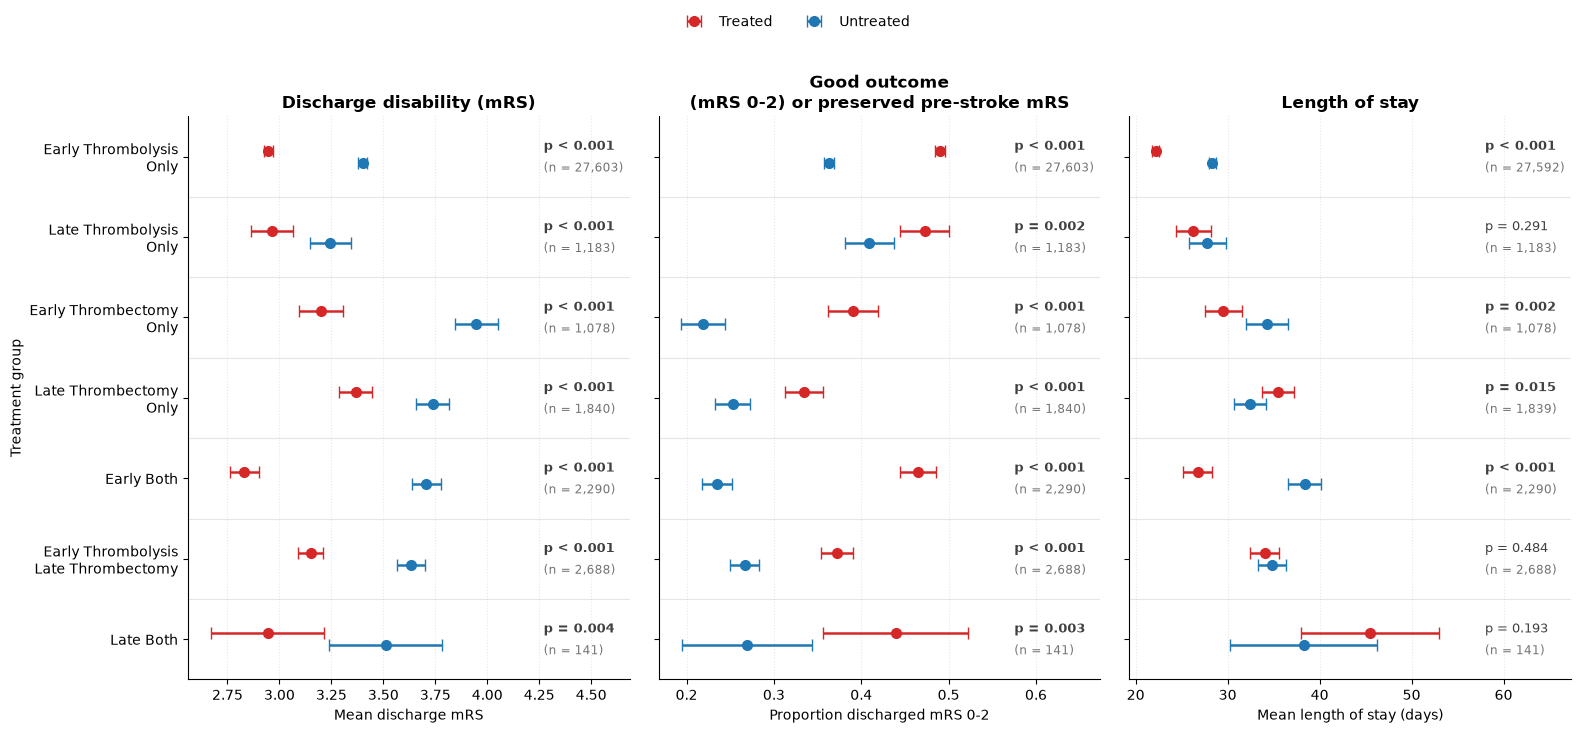

In [10]:
rename_dict = {
    'early_thrombolysis_only': 'Early Thrombolysis\nOnly',
    'late_thrombolysis_only': 'Late Thrombolysis\nOnly',
    'early_thrombectomy_only': 'Early Thrombectomy\nOnly',
    'late_thrombectomy_only': 'Late Thrombectomy\nOnly',
    'early_both': 'Early Both',
    'early_thrombolysis_late_thrombectomy': 'Early Thrombolysis\nLate Thrombectomy',
    'late_both': 'Late Both'
}

panels = [
    (summary_df.copy(), "Discharge disability (mRS)", "Mean discharge mRS"),
    (summary_df_target.copy(), "Good outcome\n(mRS 0-2) or preserved pre-stroke mRS",
     f"Proportion discharged mRS 0-{MRS_TARGET}"),
    (length_of_stay_df.copy(), "Length of stay", "Mean length of stay (days)"),
]

C_T, C_U = "#d62728", "#1f77b4"
OFF = 0.18
SPACING = 2.4

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

for ax, (df, title, xlabel) in zip(axes, panels):
    df["treatment_group"] = pd.Categorical(
        df["treatment_group"],
        categories=row_order,
        ordered=True,
    )
    df = df.sort_values("treatment_group").iloc[::-1].reset_index(drop=True)

    y = np.arange(len(df), dtype=float) * SPACING
    labels = [str(group).replace(" ", "\n", 1) for group in df["treatment_group"]]

    for suffix, offset, colour, label in [
        ("treated", OFF, C_T, "Treated"),
        ("untreated", -OFF, C_U, "Untreated"),
    ]:
        mean = np.asarray(df[f"{suffix}_mean"], dtype=float)
        lower = np.asarray(df[f"{suffix}_ci_lower"], dtype=float)
        upper = np.asarray(df[f"{suffix}_ci_upper"], dtype=float)

        ax.errorbar(
            mean,
            y + offset,
            xerr=[mean - lower, upper - mean],
            fmt="o",
            color=colour,
            ecolor=colour,
            markersize=7,
            capsize=4,
            elinewidth=1.8,
            label=label,
            zorder=3,
        )

    xmax = max(
        pd.to_numeric(df["treated_ci_upper"]).max(),
        pd.to_numeric(df["untreated_ci_upper"]).max(),
    )
    xmin = min(
        pd.to_numeric(df["treated_ci_lower"]).min(),
        pd.to_numeric(df["untreated_ci_lower"]).min(),
    )
    span = max(xmax - xmin, 1e-9)
    xtext = xmax + 0.16 * span

    for yi, p_value, n in zip(y, df["p_value"], df["matched_n"]):
        p_num = float(pd.to_numeric(p_value, errors="coerce"))
        p_text = "p < 0.001" if p_num < 0.001 else f"p = {p_num:.3f}"

        ax.text(
            xtext, yi + 0.30, p_text,
            va="center", ha="left", fontsize=9,
            fontweight="bold" if p_num < 0.05 else "normal",
            color="0.25",
        )
        ax.text(
            xtext, yi - 0.34, f"(n = {int(n):,})",
            va="center", ha="left", fontsize=8.5, color="0.45",
        )

    ax.set_xlim(xmin - 0.08 * span, xtext + 0.30 * span)

    for yi in y[:-1]:
        ax.axhline(yi + SPACING / 2, color="0.9", lw=0.8, zorder=0)

    ax.set_ylim(y[0] - SPACING / 2, y[-1] + SPACING / 2)
    ax.set_yticks(y)
    labels = [rename_dict.get(str(group), str(group)) for group in df["treatment_group"]]
    ax.set_yticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, linestyle=":")
    ax.set_axisbelow(True)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Treatment group")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.92),
)

fig.tight_layout(rect=(0, 0.05, 1, 0.90))
fig.savefig(f"./output/{prefix}.png", dpi=300)
plt.show()